# EVASPA Evaporative Fraction processing

In [151]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [152]:
import os
import numpy as np
import numpy.typing as npt
import xarray as xr
import matplotlib.pyplot as plt
from pprint import pprint
from matplotlib.colors import ListedColormap

In [153]:
from evaspa.ef import EFModel, initialize, run, check_variability
from evaspa.io import read_data_from_file
from evaspa.filter import determine_valid_pixels

In [154]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    raise Exception("Variable EVASPA_TEST_DATA_PATH must be set")

### Get test data 

In [155]:
file_path = os.path.join(
    os.environ["EVASPA_TEST_DATA_PATH"], "Landsat_20230327_28PCA.tif"
)

In [156]:
data = read_data_from_file(file_path)
data

<xarray.Dataset> Size: 188MB
Dimensions:  (y: 1832, x: 1832)
Coordinates:
  * x        (x) float64 15kB 3e+05 3.001e+05 3.002e+05 ... 4.098e+05 4.099e+05
  * y        (y) float64 15kB 1.6e+06 1.6e+06 1.6e+06 ... 1.49e+06 1.49e+06
Data variables: (12/14)
    red      (y, x) float32 13MB 0.2229 0.2041 0.1904 0.2109 ... nan nan nan nan
    blue     (y, x) float32 13MB 0.1012 0.09499 0.08831 0.09488 ... nan nan nan
    green    (y, x) float32 13MB 0.1601 0.1486 0.1398 0.152 ... nan nan nan nan
    nir      (y, x) float32 13MB 0.3612 0.3415 0.3288 0.3406 ... nan nan nan nan
    lst      (y, x) float32 13MB 323.2 323.6 323.7 323.6 ... nan nan nan nan
    emis     (y, x) float32 13MB 0.96 0.9572 0.9577 0.9591 ... nan nan nan nan
    ...       ...
    lai      (y, x) float32 13MB 0.2078 0.2222 0.237 0.2063 ... nan nan nan nan
    rsd      (y, x) float32 13MB 806.6 806.6 806.6 806.7 ... 819.9 819.9 819.9
    rld      (y, x) float32 13MB 348.8 348.9 348.9 348.9 ... 358.4 358.4 358.4
    qa       (y, x) float32 13MB 1.0 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    cloud    (y, x) float32 13MB 0.0 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0 1.0
    water    (y, x) float32 13MB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    crs:      EPSG:32628

In [157]:
coords = dict(data.sizes,band=3)
coords

{'y': 1832, 'x': 1832, 'band': 3}

In [158]:
def plot_rgb(data: xr.Dataset,bands:list[str]=["red","green","blue"]):
    rgb = xr.DataArray(
            np.dstack((data[bands[0]].data, data[bands[1]].data, data[bands[2]].data)),
            data.coords.assign(band=["r", "g", "b"]),
            dict(data.sizes, band= 3),
        )
    rgb.plot.imshow(  # type: ignore
            rgb="band",
            vmin=rgb.quantile(0.01),
            vmax=rgb.quantile(0.99),
        )
    plt.title("RGB")

def plot_band(data:xr.Dataset,band:str):
    data[band].plot.imshow(  # type: ignore
            vmin=data[band].quantile(0.01),
            vmax=data[band].quantile(0.99),
        )

def plot_mask(data:xr.Dataset,mask:str,invert=False):
    cmap = [(0.0, 0.0, 0.0, 0.0)]
    if len(np.unique(data[mask].data)) > 1:
        cmap = [(1.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 0.0)]
    if invert:
        cmap = cmap[::-1]
    valid_cmap = ListedColormap(cmap)
    data[mask].plot(cmap=valid_cmap, add_colorbar=False)


def plot(
    data: xr.Dataset, var_name: str = None, model: EFModel = None, save: bool = False
):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    if var_name is None and model is None:
        raise ValueError("Provide either var_name or model")
    lst = data["lst"].data

    if var_name is not None:
        var = data[var_name].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)

    # plot edges
    elif model is not None:
        var_name = model.var
        var = data[model.var].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min, var_max, num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)

        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel(var_name)
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()




/home/sarrazine/pyenvs/evaspa/lib/python3.10/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


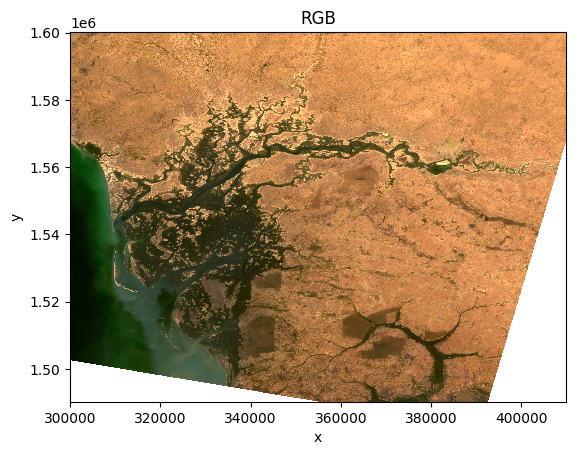

In [159]:
plot_rgb(data)

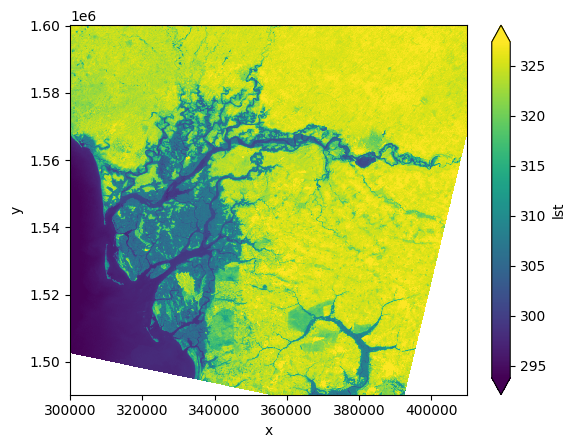

In [160]:
plot_band(data,"lst")

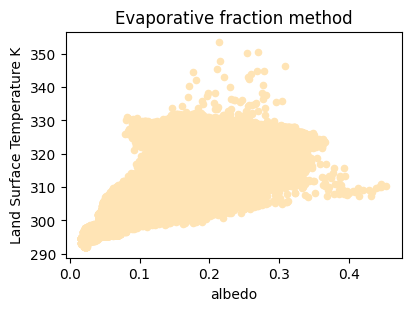

In [161]:
plot(data,"albedo")

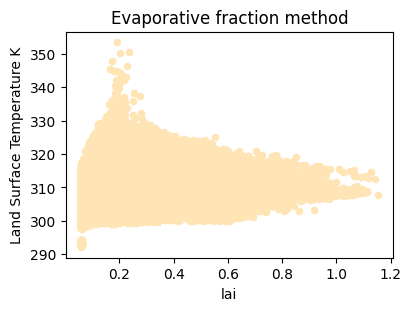

In [162]:
plot(data, "lai")

### Configuration

In [163]:
config = {
    "models": [
        {
            "name": "model1",
            "dry_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "size",
                    "interval_nb": 20,
                    "percentile": [98, 100],
                    "selection": "median",
                },
            },
            "wet_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "size",
                    "interval_nb": 20,
                    "percentile": [0, 2],
                    "selection": "median",
                },
            },
            "var": "albedo",
        },
        {
            "name": "model2",
            "dry_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "density",
                    "interval_nb": 20,
                    "percentile": [95, 100],
                    "selection": "median",
                },
            },
            "wet_edge": {
                "type": "FlatEdge",
                "config": {"selection": "min"},
            },
            "var": "lai",
        },
    ],
    "options":{
    "selection": False,
    "keep": True,
    "merging": "mean",
    },
}

In [164]:
pprint(config, sort_dicts=False)

{'models': [{'name': 'model1',
             'dry_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'size',
                                     'interval_nb': 20,
                                     'percentile': [98, 100],
                                     'selection': 'median'}},
             'wet_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'size',
                                     'interval_nb': 20,
                                     'percentile': [0, 2],
                                     'selection': 'median'}},
             'var': 'albedo'},
            {'name': 'model2',
             'dry_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'density',
                                     'interval_nb': 20,
                                     'percentile': [95, 100],
                                     'selection': 'median'}},
             'wet_edge': {'type': 'Fl

### Process evaporative fraction

#### Filter

In [165]:
data["valid"] = determine_valid_pixels(data,cloud="cloud")


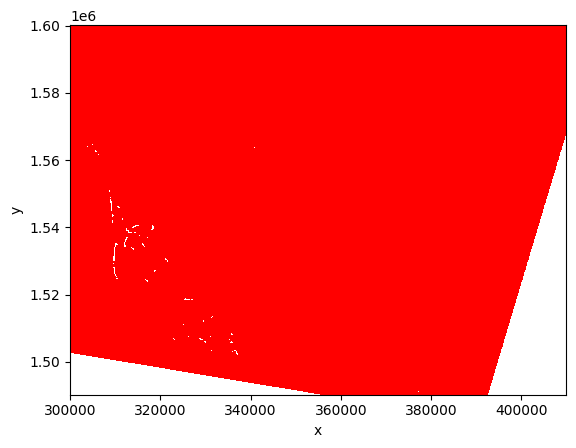

In [166]:
plot_mask(data=data,mask="valid",invert=True)

#### Check variability

In [167]:
check_variability(data["lst"],mask=data["valid"],threshold=0.1)

True

#### Compute EF

In [168]:
models, options = initialize(config)

In [169]:
ef = run(models,data,mask=None,**options)

291.91083


In [170]:
ef

<xarray.Dataset> Size: 40MB
Dimensions:  (x: 1832, y: 1832)
Coordinates:
  * x        (x) float64 15kB 3e+05 3.001e+05 3.002e+05 ... 4.098e+05 4.099e+05
  * y        (y) float64 15kB 1.6e+06 1.6e+06 1.6e+06 ... 1.49e+06 1.49e+06
Data variables:
    model1   (y, x) float32 13MB 0.0 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan nan
    model2   (y, x) float32 13MB 0.08151 0.06552 0.05665 0.07128 ... nan nan nan
    ef       (y, x) float32 13MB 0.04075 0.03276 0.02832 0.03564 ... nan nan nan

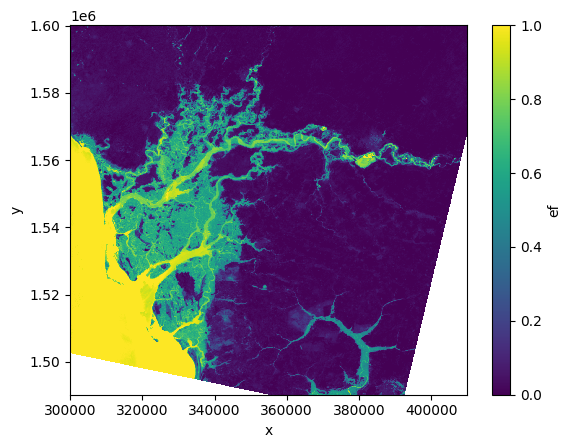

In [171]:
plot_band(ef,band="ef")

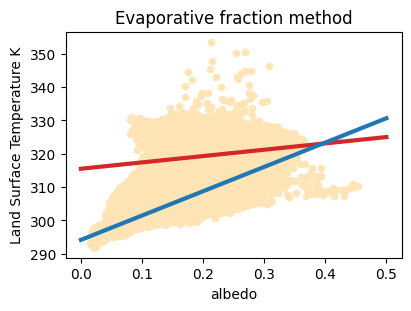

In [172]:
plot(data, model=EFModel.create(ef["model1"].attrs))

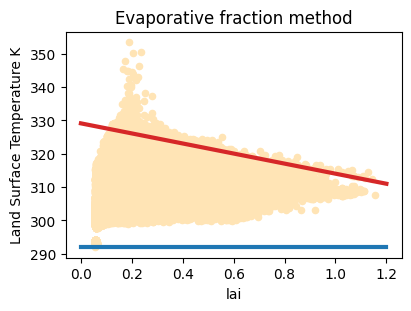

In [173]:
plot(data, model=EFModel.create(ef["model2"].attrs))